In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-survival/sample_submissions.csv
/kaggle/input/breast-cancer-survival/train_data.csv
/kaggle/input/breast-cancer-survival/test_data.csv


In [6]:
#loading data
train = pd.read_csv("/kaggle/input/breast-cancer-survival/train_data.csv")
test = pd.read_csv("/kaggle/input/breast-cancer-survival/test_data.csv")

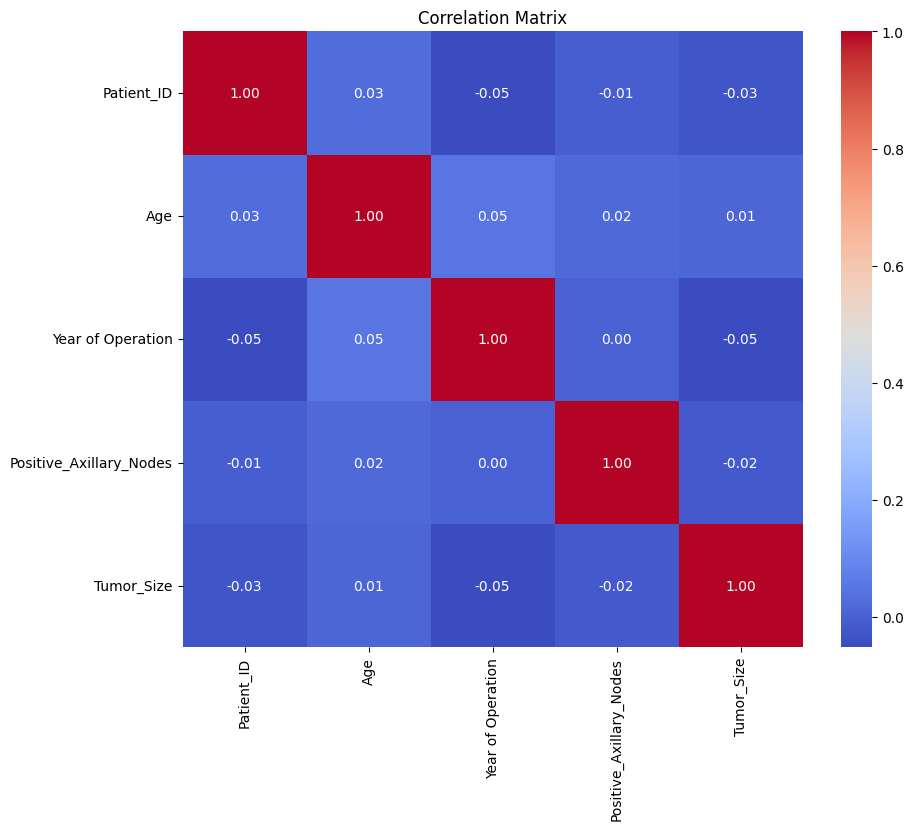

In [22]:
#checking correlation
numeric_columns = train.select_dtypes(include=[np.number])
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [7]:
train['Survival_Status'] = train['Survival_Status'].astype('category')

In [8]:
# Splitting the data into features and target
X = train.drop(columns=['Survival_Status', 'Patient_ID'])  # Dropping the target and ID
y = train['Survival_Status']

In [9]:
# Preprocessing: Normalizing numeric features and one-hot encoding nominal features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

In [10]:
# Model: A simple feed-forward neural network (MLP)
def create_mlp():
    model = Sequential()
    model.add(Dense(32, input_dim=X.shape[1], activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Assuming binary classification
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [11]:
# Building the pipeline
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(32,), max_iter=10, alpha=1.0))
])

In [12]:
# Fitting the model on the training data
mlp_pipeline.fit(X, y)

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Year of Operation', 'Positive_Axillary_Nodes', 'Tumor_Size'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Marital_Status', 'Radiation_Therapy', 'Chemotherapy',
       'Hormone_Therapy'],
      dtype='object'))])),
                ('classifier',
                 MLPClassifier(alpha=1.0, hidden_layer_sizes=(32,),
                               max_iter=10))])

In [14]:
# Making predictions on the test data
test_X = test.drop(columns=['Patient_ID'])  # Dropping ID column for prediction
predictions = mlp_pipeline.predict(test_X)

# Creating submission file
submission = pd.DataFrame({
    'Patient_ID': range(1501, 2001),
    'Survival_Status': predictions
})

In [15]:
submission.to_csv('/kaggle/working/submission3.csv', index=False)